In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
from pathlib import Path
from datetime import datetime
from src.features.feature_engine import FeatureEngine
from scipy.stats import lognorm

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)


from src.pipeline.calculate_evs import *
from src.utils.helper_functions import *
from src.features.ngboost_points import *
from src.utils.team_info import teamStarPlayer, projectedStartingFive, mainStartingFive

/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
pd.set_option('display.max_columns', None)
today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')

def get_latest_file(pattern):
    files = list(Path('data/raw/player_lines').glob(pattern))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

us_file = get_latest_file(f'NBA_US_{today}*.csv')
dfs_file = get_latest_file(f'NBA_DFS_{today}*.csv')

if us_file is None:
    raise FileNotFoundError(f"No NBA_US file found for {today}")
if dfs_file is None:
    raise FileNotFoundError(f"No NBA_DFS file found for {today}")

s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')
usData = pd.read_csv(us_file)
dfsData = pd.read_csv(dfs_file)

print(f"Loaded: {us_file.name}")
print(f"Loaded: {dfs_file.name}")
dfsData.head()

Loaded: NBA_US_20251207_104654.csv
Loaded: NBA_DFS_20251207_104754.csv


,BOOKMAKER,CATEGORY,NAME,OVER/UNDER,LINE,ODDS,COMMENCE_TIME,LAST_UPDATE,DATA_PULLED_AT
0,Betr DFS,player_points,Josh Hart,Over,18.5,-137,2025-12-07,2025-12-07T18:47:15Z,2025-12-07 10:47:54
1,Betr DFS,player_points,Josh Hart,Under,18.5,-137,2025-12-07,2025-12-07T18:47:15Z,2025-12-07 10:47:54
2,Betr DFS,player_points,Mikal Bridges,Over,14.5,-137,2025-12-07,2025-12-07T18:47:15Z,2025-12-07 10:47:54
3,Betr DFS,player_points,Mikal Bridges,Under,14.5,-137,2025-12-07,2025-12-07T18:47:15Z,2025-12-07 10:47:54
4,Betr DFS,player_points,Jaylen Brown,Over,29.5,-137,2025-12-07,2025-12-07T18:47:15Z,2025-12-07 10:47:54


In [3]:
# dfsData = pd.read_csv('data/raw/player_lines/NBA_DFS_20251206_134221.csv')
# usData = pd.read_csv('data/raw/player_lines/NBA_US_20251206_134342.csv')
# s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')

In [34]:
name = 'Tidjane Salaün'
betting_line = 7.5 
odds = 101

In [ ]:
engine = FeatureEngine({
    "min_model": "src/models/saved/min_model.pkl",
    "usg_model": "src/models/saved/usg_model.pkl",
    "fga_model": "src/models/saved/fga_model.pkl",
    "ngboost_model_wrapper": "src/models/saved/pts_model_wrapper.pkl"
})

# Get prediction
result = engine.project_player(
    player_name=name,
    data=s26,
    date="2025-12-06",
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)

print("Prediction Result:")
print(f"  Predicted Minutes: {result['predicted_minutes']:.2f}")
print(f"  Predicted Usage: {result['predicted_usage']:.3f}")
print(f"  Predicted FGA: {result['predicted_fga']:.2f}")
print(f"  Predicted Points: {result['predicted_points']:.2f}")

# Create log-normal distribution using calibrations
if engine.ngboost_model_wrapper:
    # Get the model and features
    mean_model = engine.ngboost_model_wrapper['mean_model']
    features_list = engine.ngboost_model_wrapper['features']
    variance_calibration = engine.ngboost_model_wrapper.get('variance_calibration')
    bins = engine.ngboost_model_wrapper.get('bins')
    
    # Build features (simplified - you'd need to call build_ngboost_points_features)
    # For now, let's use the predicted points to determine which bin
    median_pred = result['predicted_points']
    
    # Get distribution from model (you'll need to pass the feature_df)
    # This is a simplified example - you'd need the actual feature vector
    from src.models.ngboost_model import predict_mean
    from src.pipeline.pipeline_pts import build_ngboost_points_features
    
    feature_dict = build_ngboost_points_features(
        player_name=name,
        data=s26,
        current_date="2025-12-06",
        projectedStartingFive=projectedStartingFive,
        mainStartingFive=mainStartingFive,
        teamStarPlayer=teamStarPlayer,
        league_df=league_df,
        findOpp=findOpp,
        predicted_minutes=result['predicted_minutes'],
        predicted_usage=result['predicted_usage']
    )
    
    if feature_dict:
        feature_vector = [feature_dict.get(f, 0.0) for f in features_list]
        feature_df = pd.DataFrame([feature_vector], columns=features_list)
        feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
        
        # Get distribution parameters
        dist = mean_model.pred_dist(feature_df[features_list].fillna(feature_df[features_list].median()))
        mean_log = float(dist.loc[0])
        scale_log = float(dist.scale[0])
        var_log = scale_log ** 2
        
        # Apply calibrations based on bins
        if variance_calibration and bins:
            low_bin, medium_bin, high_bin = bins[0], bins[1], bins[2]
            if (median_pred >= low_bin[0]) and (median_pred < low_bin[1]):
                var_log *= variance_calibration.get('low', 1.0)
                print(f"\nUsing LOW bin calibration: {variance_calibration.get('low')}")
            elif (median_pred >= medium_bin[0]) and (median_pred < medium_bin[1]):
                var_log *= variance_calibration.get('medium', 1.0)
                print(f"\nUsing MEDIUM bin calibration: {variance_calibration.get('medium')}")
            elif (median_pred >= high_bin[0]) and (median_pred < high_bin[1]):
                var_log *= variance_calibration.get('high', 1.0)
                print(f"\nUsing HIGH bin calibration: {variance_calibration.get('high')}")
        
        std_log = np.sqrt(var_log)
        distribution = lognorm(s=std_log, scale=np.exp(mean_log))
        
        print(f"\nLog-Normal Distribution Parameters:")
        print(f"  Mean (log space): {mean_log:.4f}")
        print(f"  Std (log space): {std_log:.4f}")
        print(f"  Median: {median_pred:.2f}")
        print(f"  Mean: {distribution.mean():.2f}")
        print(f"  Std: {distribution.std():.2f}")
        
        samples = distribution.rvs(size=10000)
        print(f"\nDistribution Statistics (from samples):")
        print(f"  5th percentile: {np.percentile(samples, 5):.2f}")
        print(f"  25th percentile: {np.percentile(samples, 25):.2f}")
        print(f"  50th percentile (median): {np.percentile(samples, 50):.2f}")
        print(f"  75th percentile: {np.percentile(samples, 75):.2f}")
        print(f"  95th percentile: {np.percentile(samples, 95):.2f}")
        
        # Monte Carlo Simulation
        print("\n" + "="*60)
        print("MONTE CARLO SIMULATION")
        print("="*60)
        
        # Test different betting lines around the median prediction
        # Create test lines relative to the median prediction, not the betting line
        offsets = [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2]
        test_lines = [round(median_pred + offset, 1) for offset in offsets]
        test_lines = [max(0.5, line) for line in test_lines if line > 0]  # Filter and ensure positive
        
        # Also include the actual betting line if it's not already in the list
        if betting_line not in test_lines:
            test_lines.append(betting_line)
        test_lines = sorted(set(test_lines))  # Sort and remove duplicates
        
        print(f"\nTesting {len(samples):,} simulations against different lines:")
        print(f"Predicted Median: {median_pred:.2f} points")
        print(f"Betting Line: {betting_line:.1f} points")
        print(f"Test Lines: {[f'{l:.1f}' for l in test_lines]}\n")
        
        results = []
        for test_line in test_lines:
            # Calculate probabilities using distribution
            prob_over = 1 - distribution.cdf(test_line + 0.5)
            prob_under = distribution.cdf(test_line - 0.5)
            
            # Monte Carlo: count wins
            over_wins = np.sum(samples > test_line)
            under_wins = np.sum(samples < test_line)
            over_rate = over_wins / len(samples)
            under_rate = under_wins / len(samples)
            
            # Calculate expected value for different odds
            # Assuming -110 odds (1.91 decimal)
            dec_odds = 1.91
            ev_over = (prob_over * (dec_odds - 1)) - (1 - prob_over)
            ev_under = (prob_under * (dec_odds - 1)) - (1 - prob_under)
            
            results.append({
                'Line': test_line,
                'Prob_Over': prob_over,
                'Prob_Under': prob_under,
                'MC_Over_Rate': over_rate,
                'MC_Under_Rate': under_rate,
                'EV_Over': ev_over,
                'EV_Under': ev_under
            })
            
            # Determine best bet
            if ev_over > ev_under and ev_over > 0:
                best_bet = f"OVER {test_line:.1f} (EV: {ev_over:.3f})"
            elif ev_under > ev_over and ev_under > 0:
                best_bet = f"UNDER {test_line:.1f} (EV: {ev_under:.3f})"
            else:
                best_bet = "No positive EV"
            
            # Highlight the actual betting line
            line_marker = " <-- BETTING LINE" if abs(test_line - betting_line) < 0.01 else ""
            print(f"Line: {test_line:.1f}{line_marker}")
            print(f"  Over: {prob_over:.1%} (MC: {over_rate:.1%}) | EV: {ev_over:.3f}")
            print(f"  Under: {prob_under:.1%} (MC: {under_rate:.1%}) | EV: {ev_under:.3f}")
            print(f"  → {best_bet}\n")
        
        # Summary statistics
        print("="*60)
        print("SUMMARY")
        print("="*60)
        print(f"Median Prediction: {median_pred:.2f} points")
        print(f"Betting Line: {betting_line:.1f} points")
        print(f"Distribution Mean: {distribution.mean():.2f} points")
        print(f"Distribution Std: {distribution.std():.2f} points")
        print(f"\nConfidence Intervals:")
        print(f"  68% CI: [{np.percentile(samples, 16):.2f}, {np.percentile(samples, 84):.2f}]")
        print(f"  95% CI: [{np.percentile(samples, 5):.2f}, {np.percentile(samples, 95):.2f}]")
        
        # Find best EV bet
        best_ev_overall = max([(r['EV_Over'], f"OVER {r['Line']:.1f}") for r in results] + 
                              [(r['EV_Under'], f"UNDER {r['Line']:.1f}") for r in results])
        if best_ev_overall[0] > 0:
            print(f"\nBest Bet: {best_ev_overall[1]} with EV: {best_ev_overall[0]:.3f}")
        else:
            print("\nNo positive EV bets found at -110 odds")
        
        # Show EV for the actual betting line
        betting_line_result = next((r for r in results if abs(r['Line'] - betting_line) < 0.01), None)
        if betting_line_result:
            print(f"\nBetting Line ({betting_line:.1f}) Analysis:")
            print(f"  Over EV: {betting_line_result['EV_Over']:.3f}")
            print(f"  Under EV: {betting_line_result['EV_Under']:.3f}")
            if betting_line_result['EV_Over'] > betting_line_result['EV_Under']:
                print(f"  Recommendation: OVER {betting_line:.1f}")
            else:
                print(f"  Recommendation: UNDER {betting_line:.1f}")

Prediction Result:
  Predicted Minutes: 20.23
  Predicted Usage: 0.143
  Predicted FGA: 5.04
  Predicted Points: 2.26

Using LOW bin calibration: 1.15

Log-Normal Distribution Parameters:
  Mean (log space): 1.1806
  Std (log space): 0.7877
  Median: 2.26
  Mean: 4.44
  Std: 4.12

Distribution Statistics (from samples):
  5th percentile: 0.88
  25th percentile: 1.89
  50th percentile (median): 3.26
  75th percentile: 5.56
  95th percentile: 11.99

============================================================
MONTE CARLO SIMULATION
============================================================

Testing 10,000 simulations against different lines:
Predicted Median: 2.26 points
Betting Line: 7.5 points
Test Lines: ['0.5', '0.8', '1.3', '1.8', '2.3', '2.8', '3.3', '3.8', '4.3', '7.5']

Line: 0.5
  Over: 93.3% (MC: 99.1%) | EV: 0.782
  Under: 0.0% (MC: 0.9%) | EV: -1.000
  → OVER 0.5 (EV: 0.782)

Line: 0.8
  Over: 87.8% (MC: 96.2%) | EV: 0.677
  Under: 0.1% (MC: 3.8%) | EV: -0.998
  → OVER 0.8 (EV: 0.677)

Line: 1.3
  Over: 77.4% (MC: 87.4%) | EV: 0.479
  Under: 3.7% (MC: 12.6%) | EV: -0.929
  → OVER 1.3 (EV: 0.479)

Line: 1.8
  Over: 67.1% (MC: 77.1%) | EV: 0.281
  Under: 12.2% (MC: 22.9%) | EV: -0.767
  → OVER 1.8 (EV: 0.281)

Line: 2.3
  Over: 57.6% (MC: 66.8%) | EV: 0.100
  Under: 22.6% (MC: 33.2%) | EV: -0.569
  → OVER 2.3 (EV: 0.100)

Line: 2.8
  Over: 49.3% (MC: 57.4%) | EV: -0.058
  Under: 32.9% (MC: 42.6%) | EV: -0.371
  → No positive EV

Line: 3.3
  Over: 42.2% (MC: 49.3%) | EV: -0.193
  Under: 42.4% (MC: 50.7%) | EV: -0.190
  → No positive EV

Line: 3.8
  Over: 36.2% (MC: 42.1%) | EV: -0.308
  Under: 50.7% (MC: 57.9%) | EV: -0.032
  → No positive EV

Line: 4.3
  Over: 31.1% (MC: 36.5%) | EV: -0.406
  Under: 57.8% (MC: 63.5%) | EV: 0.103
  → UNDER 4.3 (EV: 0.103)

Line: 7.5 <-- BETTING LINE
  Over: 12.7% (MC: 14.9%) | EV: -0.758
  Under: 83.4% (MC: 85.1%) | EV: 0.594
  → UNDER 7.5 (EV: 0.594)

============================================================
SUMMARY
============================================================
Median Prediction: 2.26 points
Betting Line: 7.5 points
Distribution Mean: 4.44 points
Distribution Std: 4.12 points

Confidence Intervals:
  68% CI: [1.48, 7.21]
  95% CI: [0.88, 11.99]

Best Bet: OVER 0.5 with EV: 0.782

Betting Line (7.5) Analysis:
  Over EV: -0.758
  Under EV: 0.594
  Recommendation: UNDER 7.5

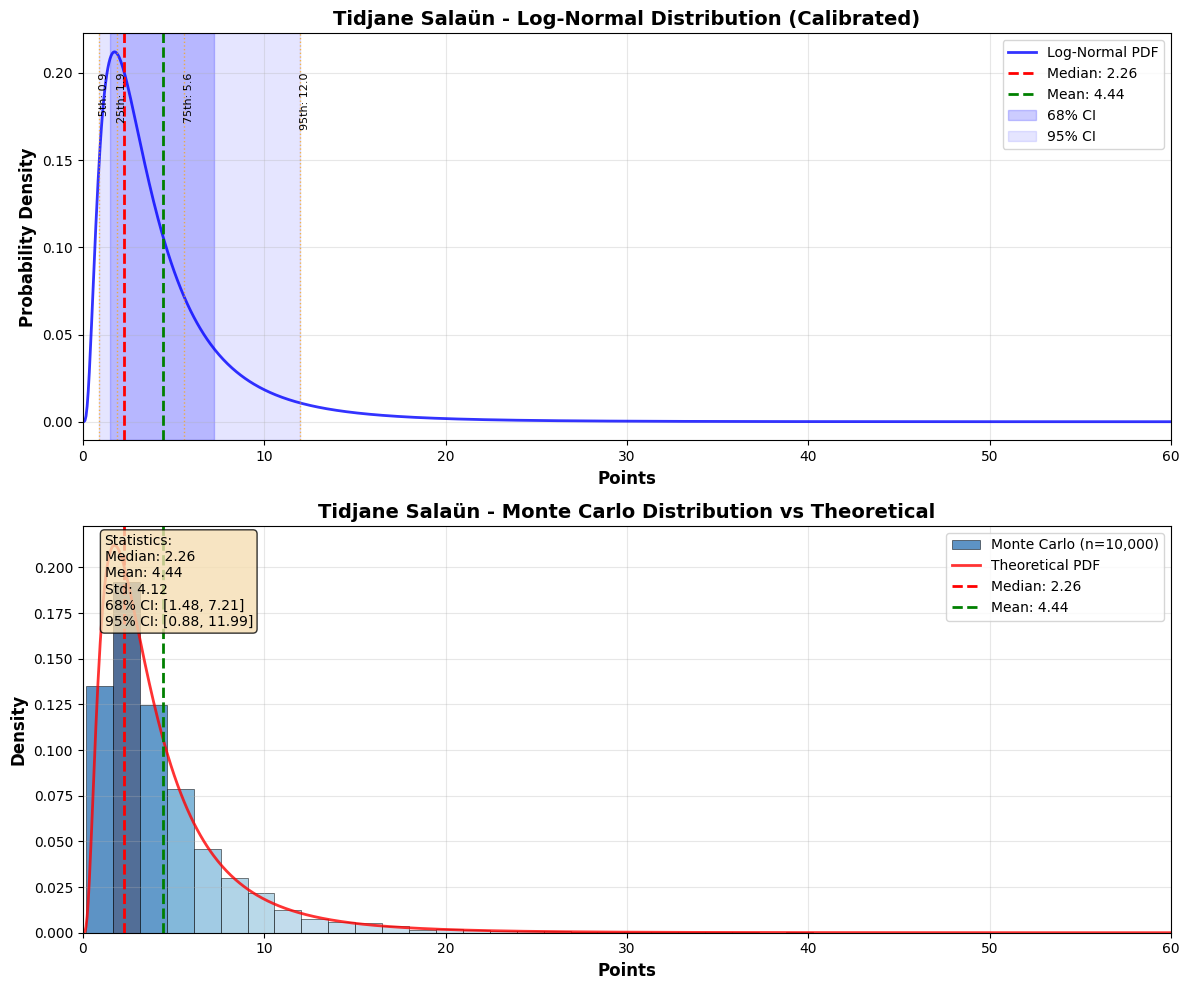

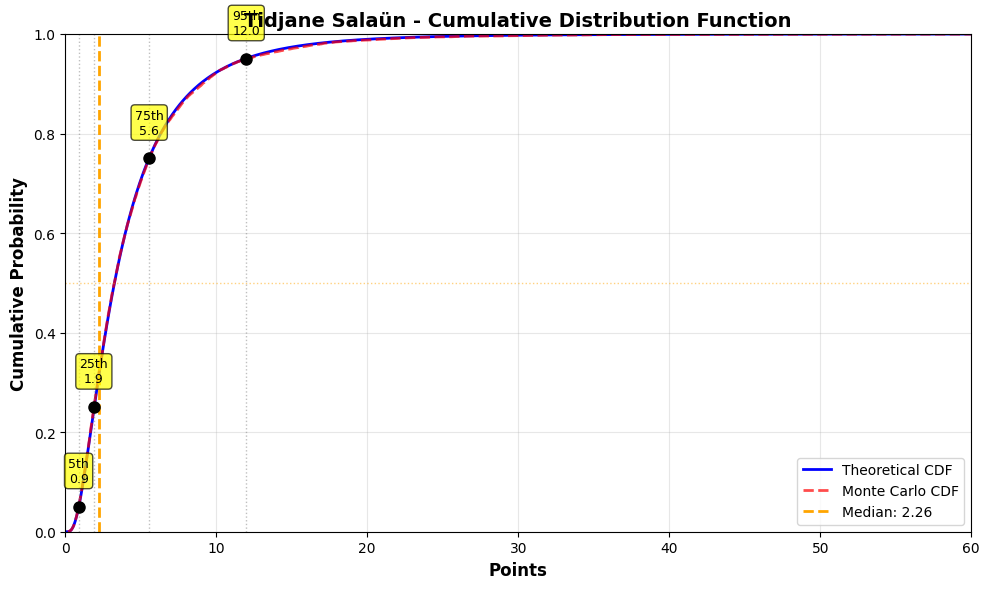

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import lognorm

# Create figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ===== TOP PLOT: Theoretical PDF with Statistics =====
ax1 = axes[0]
x = np.linspace(0, max(60, np.percentile(samples, 99)), 1000)
pdf_values = distribution.pdf(x)

# Plot PDF
ax1.plot(x, pdf_values, 'b-', linewidth=2, label='Log-Normal PDF', alpha=0.8)

# Add vertical lines for key statistics
ax1.axvline(median_pred, color='r', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax1.axvline(distribution.mean(), color='g', linestyle='--', linewidth=2, label=f'Mean: {distribution.mean():.2f}')

# Add confidence intervals
ci_68_low = np.percentile(samples, 16)
ci_68_high = np.percentile(samples, 84)
ci_95_low = np.percentile(samples, 5)
ci_95_high = np.percentile(samples, 95)

ax1.axvspan(ci_68_low, ci_68_high, alpha=0.2, color='blue', label='68% CI')
ax1.axvspan(ci_95_low, ci_95_high, alpha=0.1, color='blue', label='95% CI')

# Add percentiles
percentiles = [5, 25, 75, 95]
percentile_values = [np.percentile(samples, p) for p in percentiles]
percentile_labels = [f'{p}th: {v:.1f}' for p, v in zip(percentiles, percentile_values)]

for p_val, p_label in zip(percentile_values, percentile_labels):
    ax1.axvline(p_val, color='orange', linestyle=':', linewidth=1, alpha=0.7)
    ax1.text(p_val, ax1.get_ylim()[1] * 0.9, p_label, rotation=90, 
             verticalalignment='top', fontsize=8)

ax1.set_xlabel('Points', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax1.set_title(f'{name} - Log-Normal Distribution (Calibrated)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(60, np.percentile(samples, 99)))

# ===== BOTTOM PLOT: Monte Carlo Histogram =====
ax2 = axes[1]

# Create histogram from Monte Carlo samples
n_bins = 50
counts, bins, patches = ax2.hist(samples, bins=n_bins, density=True, alpha=0.7, 
                                  color='steelblue', edgecolor='black', linewidth=0.5,
                                  label=f'Monte Carlo (n={len(samples):,})')

# Overlay theoretical PDF
ax2.plot(x, pdf_values, 'r-', linewidth=2, label='Theoretical PDF', alpha=0.8)

# Add vertical lines for key statistics
ax2.axvline(median_pred, color='red', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax2.axvline(distribution.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {distribution.mean():.2f}')

# Color bars by density (darker = more frequent)
max_count = max(counts)
for count, patch in zip(counts, patches):
    patch.set_facecolor(plt.cm.Blues(0.3 + 0.7 * count / max_count))

# Add text box with statistics
stats_text = f'''Statistics:
Median: {median_pred:.2f}
Mean: {distribution.mean():.2f}
Std: {distribution.std():.2f}
68% CI: [{ci_68_low:.2f}, {ci_68_high:.2f}]
95% CI: [{ci_95_low:.2f}, {ci_95_high:.2f}]'''

ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax2.set_xlabel('Points', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title(f'{name} - Monte Carlo Distribution vs Theoretical', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max(60, np.percentile(samples, 99)))

plt.tight_layout()
plt.show()

# ===== Additional: CDF Plot =====
fig2, ax3 = plt.subplots(1, 1, figsize=(10, 6))

# Plot CDF
cdf_values = distribution.cdf(x)
ax3.plot(x, cdf_values, 'b-', linewidth=2, label='Theoretical CDF')

# Monte Carlo CDF (empirical)
sorted_samples = np.sort(samples)
mc_cdf = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)
ax3.plot(sorted_samples, mc_cdf, 'r--', linewidth=2, alpha=0.7, label='Monte Carlo CDF')

# Add median line
ax3.axvline(median_pred, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax3.axhline(0.5, color='orange', linestyle=':', linewidth=1, alpha=0.5)

# Add percentile markers
for p, p_val in zip([5, 25, 75, 95], percentile_values):
    ax3.axvline(p_val, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax3.plot(p_val, p/100, 'ko', markersize=8)
    ax3.text(p_val, p/100 + 0.05, f'{p}th\n{p_val:.1f}', 
             ha='center', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax3.set_xlabel('Points', fontsize=12, fontweight='bold')
ax3.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax3.set_title(f'{name} - Cumulative Distribution Function', fontsize=14, fontweight='bold')
ax3.legend(loc='lower right', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, max(60, np.percentile(samples, 99)))
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate probabilities using calibrated distribution
line = betting_line
prob_over = 1 - distribution.cdf(line + 0.5)
prob_under = distribution.cdf(line - 0.5)

if odds > 0:
    dec_odds = 1 + (odds / 100.0)
else:
    dec_odds = 1 + (100.0 / abs(odds))

# Calculate Expected Value using actual odds
ev_over = (prob_over * (dec_odds - 1)) - (1 - prob_over)
ev_under = (prob_under * (dec_odds - 1)) - (1 - prob_under)

# Determine recommendation
best_ev = max(ev_over, ev_under)
best_side = "OVER" if ev_over > ev_under else "UNDER"

print(f"\n{'='*60}")
print(f"BETTING ANALYSIS - Line: {line:.1f} | Odds: {odds:+d}")
print(f"{'='*60}")
print(f"Prediction: {median_pred:.2f} points")
print(f"Over {line:.1f}:  {prob_over:.1%} | EV: {ev_over:+.3f}")
print(f"Under {line:.1f}: {prob_under:.1%} | EV: {ev_under:+.3f}")
print(f"\n→ Recommendation: {best_side} {line:.1f} (EV: {best_ev:+.3f})")


BETTING ANALYSIS - Line: 7.5 | Odds: +101
Prediction: 2.26 points
Over 7.5:  12.7% | EV: -0.745
Under 7.5: 83.4% | EV: +0.677

→ Recommendation: UNDER 7.5 (EV: +0.677)


In [24]:
# Filter for Underdog player points
# dfsPTS = dfsData[(dfsData['BOOKMAKER'] == 'Underdog') & (dfsData['CATEGORY'] == 'player_points')]
dfsPTS = dfsData[(dfsData['BOOKMAKER'] == 'PrizePicks') & (dfsData['CATEGORY'] == 'player_points')]


really_low_volume_lines = dfsPTS[dfsPTS['LINE'].between(4.5, 8.5)]
print(f"Really low volume lines (4.5-7.5): {len(really_low_volume_lines)} bets")

low_volume_lines = dfsPTS[dfsPTS['LINE'].between(8.5, 15.5)]
print(f"Low volume lines (8.5-15.5): {len(low_volume_lines)} bets")

mid_tier_lines = dfsPTS[dfsPTS['LINE'].between(15.5, 22.5)]
print(f"Mid-tier lines (15.5-22.5): {len(mid_tier_lines)} bets")

high_volume_lines = dfsPTS[dfsPTS['LINE'].between(22.5, 35.5)]
print(f"High volume lines (22.5-35.5): {len(high_volume_lines)} bets")

ceiling_lines = dfsPTS[dfsPTS['LINE'] >= 30.5]
print(f"Ceiling lines (30.5+): {len(ceiling_lines)} bets")

Really low volume lines (4.5-7.5): 34 bets
Low volume lines (8.5-15.5): 56 bets
Mid-tier lines (15.5-22.5): 40 bets
High volume lines (22.5-35.5): 22 bets
Ceiling lines (30.5+): 2 bets


In [25]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=really_low_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 17 players...
Found 17 valid players
Generated 116 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER,TOTAL_EDGE
16,Ja'Kobe Walter,Tidjane Salaün,7.5,7.5,under,under,2.86,2.27,0.770,0.833,0.46,0.49,0.641,0.225,0.416,4.64,5.23,110,101,322,4.22,1.7058,170.58,0.1324,9.87
112,Jake LaRavia,Kenrich Williams,4.5,7.5,over,under,7.22,2.99,0.818,0.779,0.53,0.54,0.638,0.286,0.352,2.72,4.51,-120,-122,234,3.34,1.1300,113.00,0.1207,7.23
11,Jordan Walsh,Jaylin Williams,7.5,8.0,under,under,3.88,3.27,0.717,0.772,0.51,0.56,0.554,0.286,0.268,3.62,4.73,-108,-137,233,3.33,0.8433,84.33,0.0905,8.35
103,Will Richard,Justin Edwards,8.5,4.5,under,over,4.75,5.61,0.688,0.640,0.52,0.51,0.441,0.265,0.175,3.75,1.11,-114,-110,258,3.58,0.5775,57.75,0.0560,4.86
32,Sam Hauser,Sion James,6.5,6.5,over,under,7.06,4.06,0.590,0.588,0.50,0.48,0.347,0.240,0.107,0.56,2.44,-105,104,298,3.98,0.3793,37.93,0.0318,3.00
52,Ryan Kalkbrenner,Robert Williams III,8.0,6.5,under,under,5.84,4.09,0.552,0.600,0.56,0.51,0.331,0.286,0.046,2.16,2.41,-137,-110,230,3.30,0.0935,9.35,0.0102,4.57
42,Bruce Brown,Kris Murray,8.5,6.5,under,under,6.89,4.61,0.508,0.542,0.54,0.55,0.275,0.297,-0.022,1.61,1.89,-126,-128,219,3.19,-0.1222,-12.22,0.0000,3.50
108,Gabe Vincent,Svi Mykhailiuk,4.5,7.5,under,under,3.63,6.74,0.426,0.436,0.50,0.50,0.186,0.250,-0.064,0.87,0.76,-107,-107,274,3.74,-0.3050,-30.50,0.0000,1.63


In [11]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=low_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 28 players...
[MIN] No data found for Vincent Williams Jr.
Found 27 valid players
Generated 299 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER,TOTAL_EDGE
160,KJ Simpson,VJ Edgecombe,11.5,10.0,under,over,3.43,14.77,0.896,0.847,0.54,0.56,0.759,0.302,0.457,8.07,4.77,-125,-137,211,3.11,1.3615,136.15,0.1613,12.84
108,Cameron Johnson,Ace Bailey,13.5,12.5,under,under,8.83,7.69,0.719,0.738,0.46,0.52,0.531,0.239,0.291,4.67,4.81,114,-115,300,4.00,1.1227,112.27,0.0936,9.48
20,Anfernee Simons,Aaron Wiggins,11.5,15.5,over,over,14.38,19.02,0.717,0.697,0.51,0.50,0.500,0.255,0.245,2.88,3.52,-110,-104,274,3.74,0.8706,87.06,0.0794,6.40
120,Peyton Watson,Will Richard,12.5,8.5,under,under,8.53,4.75,0.681,0.688,0.50,0.52,0.469,0.260,0.209,3.97,3.75,-104,-114,268,3.68,0.7244,72.44,0.0676,7.72
247,Santi Aldama,Jusuf Nurkić,11.5,9.5,over,under,13.00,6.73,0.646,0.593,0.50,0.46,0.384,0.230,0.154,1.50,2.77,-105,112,314,4.14,0.5877,58.77,0.0468,4.27
228,Cam Spencer,Draymond Green,11.5,9.5,under,under,8.49,6.35,0.605,0.619,0.49,0.51,0.375,0.250,0.125,3.01,3.15,100,-110,282,3.82,0.4307,43.07,0.0382,6.16
254,Donovan Clingan,Rui Hachimura,9.5,11.5,over,over,9.75,11.90,0.566,0.565,0.49,0.49,0.320,0.240,0.080,0.25,0.40,100,101,302,4.02,0.2867,28.67,0.0237,0.65
82,Sandro Mamukelashvili,Matas Buzelis,9.5,14.5,under,under,7.15,12.72,0.574,0.519,0.52,0.49,0.298,0.255,0.043,2.35,1.78,-115,100,274,3.74,0.1139,11.39,0.0104,4.13
220,Toumani Camara,Quentin Grimes,12.5,14.0,under,over,11.10,14.98,0.493,0.596,0.49,0.56,0.293,0.274,0.019,1.40,0.98,-102,-137,243,3.43,0.0067,0.67,0.0007,2.38
39,Neemias Queta,Paul George,11.0,14.0,under,under,8.90,11.12,0.544,0.591,0.56,0.56,0.322,0.314,0.008,2.10,2.88,-137,-137,199,2.99,-0.0386,-3.86,0.0000,4.98


In [12]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=mid_tier_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 20 players...
Found 20 valid players
Generated 165 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER,TOTAL_EDGE
76,Brandon Miller,Aaron Wiggins,21.5,15.5,under,over,15.38,19.02,0.721,0.697,0.51,0.50,0.503,0.255,0.248,6.12,3.52,-108,-104,278,3.78,0.8998,89.98,0.0809,9.64
114,Jaren Jackson Jr.,Josh Giddey,19.5,21.5,under,under,15.99,16.98,0.634,0.696,0.48,0.50,0.441,0.240,0.201,3.51,4.52,105,-104,302,4.02,0.7730,77.30,0.0640,8.03
135,Jimmy Butler III,Keyonte George,21.5,21.5,under,under,16.52,17.95,0.693,0.621,0.53,0.50,0.431,0.265,0.166,4.98,3.55,-120,-107,255,3.55,0.5292,52.92,0.0519,8.53
53,Payton Pritchard,Jerami Grant,16.5,18.5,over,under,17.27,16.11,0.574,0.556,0.51,0.53,0.319,0.270,0.049,0.77,2.39,-111,-117,253,3.53,0.1262,12.62,0.0125,3.16
45,Immanuel Quickley,Chet Holmgren,17.5,19.5,under,under,15.70,18.17,0.521,0.492,0.52,0.49,0.256,0.255,0.002,1.80,1.33,-115,100,274,3.74,-0.0410,-4.10,0.0000,3.13
101,Kon Knueppel,Ajay Mitchell,18.5,18.0,under,over,17.19,19.02,0.488,0.567,0.49,0.56,0.277,0.274,0.002,1.31,1.02,-102,-137,243,3.43,-0.0505,-5.05,0.0000,2.33
8,Scottie Barnes,Coby White,20.5,19.5,under,under,18.96,18.37,0.503,0.473,0.51,0.49,0.238,0.250,-0.012,1.54,1.13,-110,100,282,3.82,-0.0916,-9.16,0.0000,2.67
152,Nikola Vučević,LeBron James,15.5,17.5,under,under,14.93,16.23,0.430,0.487,0.46,0.51,0.209,0.235,-0.025,0.57,1.27,114,-110,309,4.09,-0.1443,-14.43,0.0000,1.84
77,Miles Bridges,Shaedon Sharpe,21.5,22.5,under,under,21.37,22.14,0.418,0.430,0.50,0.53,0.180,0.265,-0.085,0.13,0.36,-106,-117,260,3.60,-0.3528,-35.28,0.0000,0.49
26,Derrick White,Joel Embiid,18.0,17.5,under,under,17.98,17.48,0.406,0.408,0.56,0.51,0.166,0.286,-0.120,0.02,0.02,-137,-110,230,3.30,-0.4534,-45.34,0.0000,0.04


In [13]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=high_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 11 players...
Found 11 valid players
Generated 48 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER,TOTAL_EDGE
18,Nikola Jokić,Deni Avdija,29.5,25.5,under,under,23.79,20.30,0.693,0.711,0.53,0.53,0.492,0.281,0.212,5.71,5.20,-118,-119,240,3.40,0.6744,67.44,0.0702,10.91
14,Brandon Ingram,Tyrese Maxey,23.5,27.5,under,over,20.83,28.46,0.572,0.590,0.51,0.49,0.338,0.250,0.088,2.67,0.96,-110,100,282,3.82,0.2899,28.99,0.0257,3.63
7,Jaylen Brown,Jalen Williams,28.5,23.5,over,under,29.16,20.90,0.572,0.556,0.52,0.51,0.318,0.265,0.053,0.66,2.60,-115,-110,257,3.57,0.1347,13.47,0.0131,3.26
43,Luka Dončić,Lauri Markkanen,32.5,23.5,under,over,30.96,24.41,0.502,0.586,0.52,0.54,0.294,0.281,0.014,1.54,0.91,-115,-125,237,3.37,-0.0080,-0.80,0.0000,2.45
29,Jamal Murray,Austin Reaves,23.5,23.0,under,under,23.05,21.82,0.439,0.481,0.48,0.56,0.211,0.269,-0.058,0.45,1.18,105,-137,255,3.55,-0.2506,-25.06,0.0000,1.63


In [14]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=ceiling_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                   
    max_player_appearances=1,   
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Not enough players for 2-leg bets


""
